In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN
from kmedoids import KMedoids
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster

In [3]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], descriptors=["acsf"])
df = qm9.load()
molecules = qm9.get_molecules()

2026-04-27 09:46:16.712 | INFO     | src.datasets:load:818 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-27 09:46:17.140 | INFO     | src.datasets:_sample_qm9_df:1018 - QM9 sampling complete: strategy=stratified, requested_limit=5500, returned_rows=5500.
2026-04-27 09:46:17.141 | INFO     | src.datasets:_add_requested_descriptors:199 - Applying requested QM9 descriptors to sampled dataframe (rows=5500).
2026-04-27 09:46:17.147 | INFO     | src.features:compute_acsf:315 - Computing ACSF (rcut=6.0)...
2026-04-27 09:46:19.534 | SUCCESS  | src.datasets:add_acsf:1186 - Added ACSF embeddings.
2026-04-27 09:46:19.534 | INFO     | src.datasets:_add_requested_descriptors:224 - Added descriptor column(s): ['acsf_embedding']
2026-04-27 09:46:19.539 | INFO     | src.datasets:load:857 - QM9 descriptor null-filtering complete: attempts=1, requested_limit=5000, returned_rows=5000, base_rows=5500.
2026-04-27 09:46:41.386 | SUCCESS  | src.datasets:get_molecules:1588 -

In [4]:
len(molecules[0:2])

2

In [5]:
plot_molecules_with_py3dmol(molecules[0:3])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [6]:
dist_matrix = qm9.get_distance_matrix(
    descriptor="acsf",
    dist_type="euclidean",
    force_calculate=True
)

2026-04-27 09:46:41.430 | INFO     | src.datasets:get_distance_matrix:1419 - Calculating distance matrix for acsf using euclidean distance.
2026-04-27 09:46:41.833 | SUCCESS  | src.distance:_compute_and_save:74 - Saved distance matrix to data/QM9/dist_acsf_euclidean.npy


# Determining the best number of clusters for each clustering method

Evaluating epsilon and min samples: 100%|██████████| 10/10 [00:08<00:00,  1.25it/s]


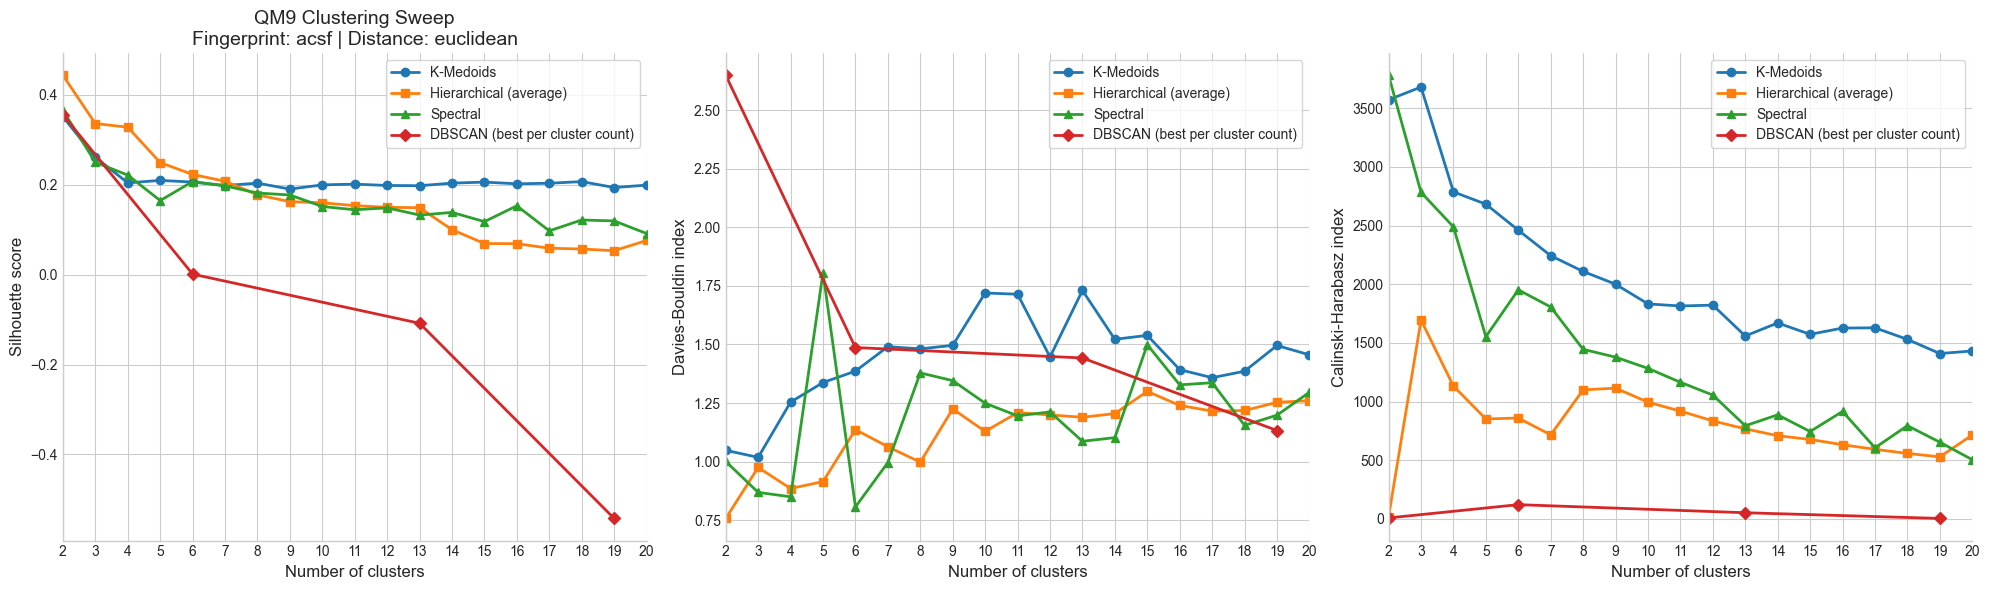

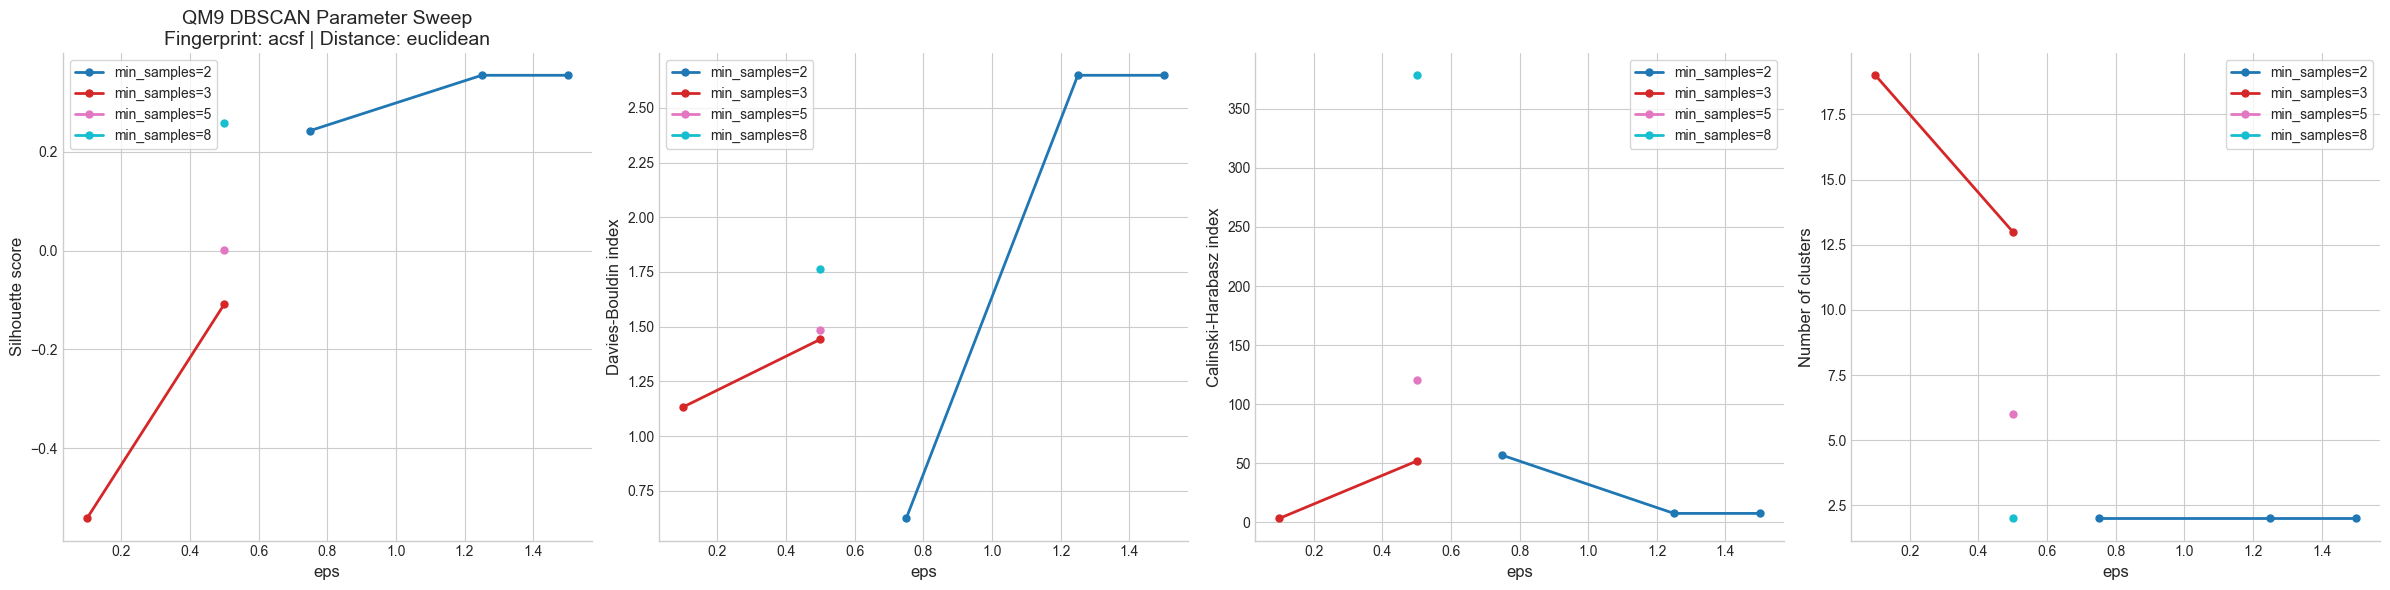

2026-04-27 09:47:44.314 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:984 - Saved clustering sweep plot to figures/qm9/clustering/euclidean/acsf/clustering_sweep_2_to_20_clusters.png
2026-04-27 09:47:44.314 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:986 - Saved DBSCAN evaluation plot to figures/qm9/clustering/euclidean/acsf/dbscan_parameter_sweep.png
2026-04-27 09:47:44.314 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:987 - Saved clustering sweep results to figures/qm9/clustering/euclidean/acsf/clustering_sweep_2_to_20_clusters.json


In [7]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="acsf",
    distance_metric="euclidean",
    dataset_name="qm9",
)

In [8]:
# find the n molecules that are not on the diagonal with the smallest distance
n = 10
# Get the indices of the upper triangle (excluding diagonal)
triu_indices = np.triu_indices_from(dist_matrix, k=1)
# Get the distances and corresponding molecule pairs
distances = dist_matrix[triu_indices]
molecule_pairs = list(zip(triu_indices[0], triu_indices[1]))
# Get the indices of the n smallest distances
smallest_indices = np.argsort(distances)[:n]
# Get the corresponding molecule pairs for the n smallest distances
closest_pairs = [molecule_pairs[i] for i in smallest_indices]
print("Closest molecule pairs (indices):", closest_pairs)
mols = [(molecules[idx1], molecules[idx2]) for idx1, idx2 in closest_pairs]

Closest molecule pairs (indices): [(np.int64(1173), np.int64(1820)), (np.int64(981), np.int64(987)), (np.int64(1034), np.int64(1051)), (np.int64(1886), np.int64(1912)), (np.int64(760), np.int64(803)), (np.int64(981), np.int64(983)), (np.int64(1132), np.int64(1196)), (np.int64(1048), np.int64(1052)), (np.int64(1037), np.int64(1052)), (np.int64(2260), np.int64(4470))]


In [9]:
print(mols[0])

(Atoms(symbols='H5CH3CO2C2NC2', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='H2NCH5COC4O', pbc=False, initial_charges=..., mass=..., partial_charge=...))


In [10]:
plot_molecules_with_py3dmol(mols[1])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Hiercical Clustering on Distance Matrix

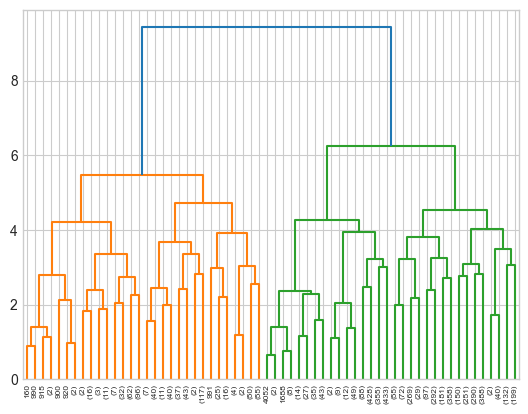

In [11]:
condensed_dist = squareform(dist_matrix)
Z = linkage(condensed_dist, method='complete')
a = dendrogram(
    Z,
    truncate_mode='level',
    p=5                
)

In [12]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=2, linkage='complete')
labels_hier = model_hier.fit_predict(dist_matrix)
df = df.with_columns(labels_hier=labels_hier)

In [13]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [14]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="acsf",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

2026-04-27 09:48:09.902 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:529 - Saved PCA projection plot to figures/qm9/clustering/euclidean/acsf/pca_hierarchical_projection.png


{'coords': array([[ 28.27755802,   8.85644182],
        [ 65.47758517,   2.01908086],
        [ 89.56384651,  33.70902932],
        ...,
        [ 34.25412166,  13.42321536],
        [-36.71588183,  -7.15688618],
        [ -2.55257903, -15.88029307]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/acsf/pca_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/acsf'),
 'clustering_method': 'hierarchical'}

In [15]:
average_numeric_by_cluster(df, "labels_hier")

shape: (2, 71)
┌─────────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬─────────────────┬───────────┬─────────────────┬──────────────┬─────────────────┬───────────┬──────────────┬─────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬─────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬─────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_hier,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,4312,2.100571,0.0,123.169991,0.121753,32.651438,0.896368,12.82217,8.809833,1.771568,0.058442,0.000928,2.157468,19.14077,2.071137,2.388451,0.058421,0.154957,0.786621,0.906308,1.812152,6.776206,0.400742,0.991187,5.260436,6.337662,40.367579,1.262587,0.001855,0.401438,0.013683,0.103896,0.116419,0.002319,0.033163,0.130798,0.563312,0.0,2.563434,76.607655,-6.521435,0.557208,7.078679,1195.853506,4.316374,-11053.234853,-11052.999591,-11052.973896,-11054.147368,32.444203,-79.052598,-79.544402,-80.003573,-73.537567,3.213674,1.393152,1.129945,84.763451,5.797774,9.438776,40.367579,1347,"""Acyclic""",9.438776,311,"""C1CC1""",10.250464,1,null,0.0
1,688,1.827625,0.0,118.837209,-0.210756,55.071221,0.748228,12.904254,8.540698,1.059593,0.452035,0.027616,3.482558,14.486919,2.006112,1.671512,0.139985,0.505582,0.354433,1.043605,2.795058,5.122093,0.809593,2.436047,1.8125,6.303779,26.6875,1.262212,0.0,0.177326,0.085756,0.315407,0.22093,0.002907,0.09157,0.146802,0.447674,0.001453,3.35533,68.456642,-6.629813,-0.811659,5.81821,1121.990153,2.866015,-11474.289989,-11474.075099,-11474.049418,-11475.188222,28.300324,-62.933313,-63.263313,-63.600945,-58.785837,4.317399,1.457349,1.097541,38.517442,43.168605,18.313953,26.6875,250,"""Acyclic""",18.313953,62,"""C1CCCC1""",26.889535,1,null,0.0


# KMedoids

In [16]:
model_km = KMedoids(n_clusters=3, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
df = df.with_columns(labels_km=labels_km)
print(np.unique(labels_km, return_counts=True))

(array([0, 1, 2], dtype=uint64), array([1963, 1904, 1133]))


In [17]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [18]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="acsf",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

2026-04-27 09:48:33.621 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:529 - Saved PCA projection plot to figures/qm9/clustering/euclidean/acsf/pca_kmedoids_projection.png


{'coords': array([[ 28.27755802,   8.85644182],
        [ 65.47758517,   2.01908086],
        [ 89.56384651,  33.70902932],
        ...,
        [ 34.25412166,  13.42321536],
        [-36.71588183,  -7.15688618],
        [ -2.55257903, -15.88029307]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/acsf/pca_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/acsf'),
 'clustering_method': 'kmedoids'}

In [19]:
average_numeric_by_cluster(df, "labels_km")

shape: (3, 72)
┌───────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_km,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,1963,2.16828,0.0,123.540499,0.450331,23.817626,0.923469,12.807667,8.83189,1.863984,0.002547,0.0,1.594498,20.904228,2.072437,2.697911,0.03313,0.0814,0.88547,0.771778,1.379521,7.325013,0.246052,0.597045,6.394294,6.338767,45.382578,1.259623,0.0,0.448293,0.0,0.03515,0.055018,0.001528,0.013245,0.087112,0.462048,0.0,2.142159,80.233169,-6.521694,1.120767,7.642482,1219.93427,4.903427,-10709.004073,-10708.761448,-10708.735746,-10709.919108,34.011721,-85.397918,-85.953891,-86.460789,-79.351941,2.997588,1.3877,1.146427,0.0,90.779419,0.254712,8.965869,45.382578,694,"""Acyclic""",8.965869,212,"""C1CC1""",9.933775,1,null,0.0
1,1904,2.063629,0.0,123.245798,-0.147059,38.507353,0.90535,12.821066,8.799895,1.801471,0.047269,0.001576,2.555147,17.856092,2.080709,2.156513,0.067926,0.180126,0.751948,0.95063,2.164391,6.342437,0.462185,1.130777,4.651786,6.277311,36.894433,1.267129,0.002101,0.417017,0.005252,0.121324,0.141282,0.002626,0.060399,0.184349,0.740546,0.0,2.861146,73.279848,-6.575363,0.131519,6.706931,1163.606246,3.891273,-11389.303562,-11389.075036,-11389.049335,-11390.21225,31.192563,-74.407789,-74.854984,-75.279898,-69.271659,3.332585,1.412608,1.140652,0.021534,86.344538,4.726891,8.928571,36.894433,741,"""Acyclic""",8.928571,229,"""C1CC1""",10.92437,1,null,0.0
2,1133,1.879599,0.0,119.769638,-0.197705,51.729921,0.744363,12.898998,8.62489,1.128861,0.413063,0.017652,3.269197,15.418358,2.013314,1.806708,0.135797,0.453018,0.411185,1.148279,2.566637,5.549868,0.813769,2.316858,2.225066,6.416593,29.208297,1.259862,0.00353,0.157988,0.095322,0.322154,0.244484,0.00353,0.05737,0.126214,0.370697,0.000883,3.273887,70.968967,-6.49617,-0.535056,5.961169,1163.470681,3.132931,-11340.557124,-11340.335669,-11340.310005,-11341.463031,29.315428,-66.076239,-66.433576,-66.793824,-61.674797,4.058452,1.408887,1.063718,0.57105,43.601059,39.894086,16.504854,29.208297,379,"""Acyclic""",16.504854,79,"""C1CCCC1""",25.242718,1,null,0.0


# Spectral

In [20]:
model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(dist_matrix)
df = df.with_columns(labels_spectral=labels_spectral)
print(np.unique(labels_spectral, return_counts=True))

(array([0, 1, 2], dtype=int32), array([4998,    1,    1]))


In [21]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [22]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="acsf",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

2026-04-27 09:54:25.429 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:529 - Saved PCA projection plot to figures/qm9/clustering/euclidean/acsf/pca_spectral_projection.png


{'coords': array([[ 28.27755802,   8.85644182],
        [ 65.47758517,   2.01908086],
        [ 89.56384651,  33.70902932],
        ...,
        [ 34.25412166,  13.42321536],
        [-36.71588183,  -7.15688618],
        [ -2.55257903, -15.88029307]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/acsf/pca_spectral_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/acsf'),
 'clustering_method': 'spectral'}

In [23]:
average_numeric_by_cluster(df, "labels_spectral")

shape: (3, 73)
┌────────────────┬───────┬────────────────┬─────────────┬────────────┬─────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬─────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

labels_spectral,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,4998,2.063027,0.0,122.572629,0.076431,35.733093,0.875977,12.833476,8.772709,1.673469,0.112445,0.004602,2.339536,18.5012,2.062166,2.290716,0.069672,0.203051,0.727276,0.92517,1.947379,6.548419,0.457183,1.189076,4.786915,6.333133,38.487195,1.262533,0.001601,0.370748,0.023609,0.132653,0.130852,0.002401,0.041016,0.133053,0.547419,0.0002,2.668081,75.482453,-6.537588,0.369162,6.906789,1185.707564,4.117075,-11110.850598,-11110.618126,-11110.592433,-11111.761163,31.87547,-76.837535,-77.307096,-77.749566,-71.510452,3.365066,1.402059,1.125542,0.137655,0.833934,78.411365,10.92437,10.664266,38.487195,1502,"""Acyclic""",10.664266,317,"""C1CCCC1""",10.844338,1,null,0.0
1,1,2.058824,0.0,126.0,-1.0,42.0,0.889912,12.830556,9.0,2.0,0.0,0.0,3.0,17.0,2.117647,0.0,0.0,0.5,0.5,1.0,2.0,7.0,0.0,3.0,3.0,6.0,35.0,1.270621,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,13.4634,84.540001,-3.436798,-0.40545,3.031348,1141.575439,3.440853,-11914.456055,-11914.255859,-11914.230469,-11915.326172,28.215,-69.460281,-69.87735,-70.262848,-64.703026,4.56545,1.21928,0.98521,0.0,1.0,100.0,0.0,0.0,35.0,1,"""O=C1C=C2C[NH2+]CC2O1""",100.0,1,"""CC1CC2CCCC2C1""",100.0,1,null,0.0
2,1,2.0,0.0,125.0,-1.0,46.0,0.898394,12.782563,9.0,2.0,1.0,0.0,3.0,16.0,2.125,0.0,0.0,0.666667,0.333333,1.0,2.0,7.0,0.0,4.0,2.0,6.0,32.0,1.264755,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,13.4626,84.540001,-3.436798,-0.40545,3.031348,1141.563354,3.440853,-11914.456055,-11914.255859,-11914.230469,-11915.326172,28.215,-69.460251,-69.87735,-70.262848,-64.702995,4.56564,1.21928,0.98523,0.0,1.0,0.0,100.0,0.0,32.0,1,"""O=c1[c-]c2c(o1)C[NH2+]C2""",100.0,1,"""CC1CC2CCCC2C1""",100.0,1,null,0.0


# DBSCAN 

In [24]:
model_db = DBSCAN(
    eps=0.6,
    min_samples=2,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db, return_counts=True))

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9]), array([  29, 4951,    2,    2,    2,    3,    2,    2,    2,    3,    2]))


In [25]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [26]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="acsf",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

2026-04-27 09:54:48.731 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:529 - Saved PCA projection plot to figures/qm9/clustering/euclidean/acsf/pca_dbscan_projection.png


{'coords': array([[ 28.27755802,   8.85644182],
        [ 65.47758517,   2.01908086],
        [ 89.56384651,  33.70902932],
        ...,
        [ 34.25412166,  13.42321536],
        [-36.71588183,  -7.15688618],
        [ -2.55257903, -15.88029307]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/acsf/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/acsf'),
 'clustering_method': 'dbscan'}

In [27]:
average_numeric_by_cluster(df, "labels_db")

shape: (11, 74)
┌───────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬─────────┬────────┬────────┬─────────────┬───────────┬───────────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────

labels_db,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,29,1.750466,0.0,109.724138,-0.172414,56.448276,0.746129,13.237951,7.655172,0.62069,0.448276,0.586207,4.0,12.034483,1.935102,1.310345,0.122414,0.585632,0.291954,0.931034,2.896552,4.137931,0.482759,2.068966,1.103448,5.241379,21.62069,1.26578,0.0,0.0,0.068966,0.344828,0.241379,0.068966,0.034483,0.103448,0.068966,0.034483,3.501679,55.26862,-7.061824,-1.002036,6.0596,859.823211,2.32006,-11247.302566,-11247.11382,-11247.088244,-11248.159365,24.444621,-52.070083,-52.342529,-52.624316,-48.600384,5.929278,1.993227,1.513861,0.827586,1.793103,0.0,13.793103,44.827586,41.37931,21.62069,17,"""Acyclic""",41.37931,8,"""Acyclic""",41.37931,1,null,0.0
0,4951,2.065941,0.0,122.687538,0.077156,35.541507,0.877434,12.830631,8.782064,1.681277,0.109675,0.001212,2.324985,18.560695,2.063055,2.300343,0.069112,0.199798,0.73109,0.926883,1.936982,6.5714,0.456271,1.182791,4.818017,6.341749,38.643506,1.262471,0.001616,0.374268,0.023026,0.131489,0.129873,0.00202,0.040396,0.133104,0.549384,0.0,2.66585,75.663817,-6.531316,0.381828,6.913185,1188.599582,4.133917,-11110.178665,-11109.945786,-11109.920092,-11111.089705,31.944905,-77.060924,-77.532312,-77.976273,-71.716684,3.328137,1.396855,1.122265,0.130479,0.82448,0.000606,78.933549,10.644314,10.422137,38.643506,1491,"""Acyclic""",10.422137,316,"""C1CCCC1""",10.725106,1,null,0.0
1,2,1.572727,0.0,90.0,0.0,52.0,0.578957,13.003101,6.5,0.5,0.5,0.0,3.0,10.5,1.909091,0.5,0.25,0.75,0.0,1.5,2.5,3.5,1.0,2.5,0.0,6.0,16.5,1.230269,0.0,0.0,0.0,0.5,0.5,0.0,0.0,0.0,0.0,0.0,3.52515,51.050001,-6.30896,-0.306128,6.004192,636.175598,2.079698,-8718.516602,-8718.352051,-8718.327148,-8719.325195,21.2145,-46.326912,-46.567625,-46.811766,-43.365866,8.769205,2.752875,2.04988,1.0,2.0,0.0,0.0,50.0,50.0,16.5,2,"""c1cocn1""",50.0,2,"""Acyclic""",50.0,1,null,0.0
2,2,1.666667,0.0,78.0,1.0,0.0,1.008157,12.429361,6.0,0.0,0.0,0.0,0.0,12.0,1.833333,0.0,0.666667,0.0,0.333333,0.0,0.0,2.0,4.0,0.0,2.0,7.0,20.0,1.225834,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.37355,65.429998,-6.454541,0.609535,7.064076,945.323669,2.556074,-6314.405762,-6314.201172,-6314.175293,-6315.292969,24.3345,-53.548447,-53.806396,-54.089111,-50.321163,46.278743,1.309205,1.239675,1.0,2.0,0.0,0.0,0.0,100.0,20.0,1,"""Acyclic""",100.0,1,"""Acyclic""",100.0,1,null,0.0
3,2,1.606061,0.0,106.0,0.0,73.5,0.174744,13.421393,7.5,1.0,1.0,0.0,5.0,11.5,2.0,1.5,0.0,0.833333,0.166667,1.5,4.5,4.0,0.0,2.0,0.5,5.0,18.5,1.254679,0.0,0.0,0.5,0.5,0.0,0.0,0.0,0.0,0.0,0.0,3.28255,52.459999,-7.046388,-1.029951,6.016437,736.820892,2.233891,-10661.262695,-10661.083984,-10661.058105,-10662.10498,23.001,-48.331522,-48.595743,-48.865574,-44.981432,4.433695,2.656565,1.577415,1.0,2.0,0.0,0.0,100.0,0.0,18.5,2,"""c1c[nH]nn1""",50.0,1,"""C1CCCC1""",100.0,1,null,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,

In [28]:
from src.helper_functions import evaluate_hdbscan_grid
import hdbscan
a = evaluate_hdbscan_grid(dist_matrix)


Top configurations:

mcs=80, ms=1, clusters=13, noise=0.51, persistence=0.124, score=0.061
mcs=60, ms=1, clusters=16, noise=0.47, persistence=0.113, score=0.060
mcs=40, ms=1, clusters=21, noise=0.45, persistence=0.100, score=0.055
mcs=120, ms=1, clusters=8, noise=0.41, persistence=0.090, score=0.053
mcs=150, ms=1, clusters=2, noise=0.20, persistence=0.058, score=0.046
mcs=40, ms=4, clusters=19, noise=0.56, persistence=0.099, score=0.044
mcs=20, ms=1, clusters=40, noise=0.37, persistence=0.069, score=0.043
mcs=10, ms=1, clusters=92, noise=0.34, persistence=0.065, score=0.043
mcs=10, ms=1, clusters=92, noise=0.34, persistence=0.065, score=0.043
mcs=300, ms=1, clusters=2, noise=0.45, persistence=0.070, score=0.039


In [29]:
clusterer = hdbscan.HDBSCAN(
        min_cluster_size=40,
        min_samples=4,
        metric='precomputed',
    )

labels_hdbscan = clusterer.fit_predict(dist_matrix.astype(np.float64))
df = df.with_columns(labels_hdbscan=labels_hdbscan)

In [30]:
create_chemiscope_viewer(df, dist_matrix, labels_hdbscan, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [31]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="acsf",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hdbscan,
    clustering_method="hdbscan"
)

2026-04-27 09:55:51.117 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:529 - Saved PCA projection plot to figures/qm9/clustering/euclidean/acsf/pca_hdbscan_projection.png


{'coords': array([[ 28.27755802,   8.85644182],
        [ 65.47758517,   2.01908086],
        [ 89.56384651,  33.70902932],
        ...,
        [ 34.25412166,  13.42321536],
        [-36.71588183,  -7.15688618],
        [ -2.55257903, -15.88029307]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/euclidean/acsf/pca_hdbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/euclidean/acsf'),
 'clustering_method': 'hdbscan'}

In [32]:
average_numeric_by_cluster(df, "labels_hdbscan")

shape: (20, 75)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────

labels_hdbscan,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,2799,2.008471,0.0,120.938192,0.043587,40.263666,0.850918,12.850378,8.654877,1.360486,0.16756,0.008217,2.551983,17.666309,2.033384,2.396927,0.10222,0.242164,0.655616,0.952483,2.120043,6.046802,0.662022,1.332976,4.107896,6.418721,35.83637,1.259011,0.002144,0.355127,0.032154,0.186852,0.147195,0.00393,0.047874,0.126474,0.518757,0.000357,2.850942,73.8312,-6.615976,0.150066,6.766085,1203.826775,3.864426,-11092.692059,-11092.459205,-11092.433526,-11093.607356,31.385328,-73.748541,-74.185263,-74.606077,-68.680101,3.673268,1.385948,1.106469,0.23294,1.095748,0.001072,0.026081,65.702036,16.184352,18.113612,35.83637,799,"""Acyclic""",18.113612,206,"""Acyclic""",18.113612,1,null,0.0
0,137,2.20206,0.0,121.817518,0.10219,24.729927,0.756978,12.849564,8.905109,2.291971,0.094891,0.0,1.649635,20.562044,2.117802,2.051095,0.074296,0.094369,0.831335,1.153285,1.124088,7.948905,0.518248,0.693431,6.043796,6.175182,45.357664,1.262289,0.0,0.0,0.0,0.087591,0.0,0.0,0.0,0.0,0.0,0.0,2.679638,82.120437,-6.171562,1.170189,7.341831,1165.785612,4.702523,-10157.622605,-10157.389492,-10157.363745,-10158.522689,33.03911,-83.439079,-83.979017,-84.468881,-77.559092,2.971363,1.428863,1.178662,0.0,0.189781,0.0,0.0,89.051095,9.489051,1.459854,45.357664,87,"""C1C[NH2+]1""",4.379562,43,"""C1CCCC1""",9.489051,1,null,0.0
1,42,1.974376,0.0,123.0,0.0,39.285714,1.049663,12.603726,8.952381,2.261905,0.0,0.0,2.571429,14.714286,2.146032,0.761905,0.148526,0.241497,0.609977,0.214286,2.571429,5.380952,1.0,1.52381,3.857143,5.738095,29.047619,1.295128,0.0,0.214286,0.0,0.0,0.0,0.0,0.238095,0.571429,1.02381,0.0,3.469731,69.265952,-6.96592,-1.076858,5.888933,1052.725579,2.951594,-11836.674688,-11836.465425,-11836.439546,-11837.559268,28.720786,-66.993462,-67.351217,-67.703656,-62.635261,3.082389,1.484221,1.170819,0.02381,1.285714,0.0,0.0,100.0,0.0,0.0,29.047619,31,"""O=C1CC2OC12""",7.142857,21,"""CC1CC2CC12""",16.666667,1,null,0.0
2,110,2.230278,0.0,119.590909,1.936364,1.881818,0.947927,12.66916,8.854545,2.281818,0.0,0.0,0.081818,22.027273,2.104414,1.654545,0.049026,0.127597,0.823377,0.0,0.081818,8.345455,0.427273,1.127273,7.218182,6.327273,49.172727,1.265779,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.667509,88.226182,-6.406995,1.210115,7.617011,1192.02961,5.324597,-9427.171444,-9426.938836,-9426.913104,-9428.065518,33.942118,-92.359136,-92.973419,-93.512509,-85.944431,2.990832,1.446269,1.200575,0.0,0.0,0.0,0.0,100.0,0.0,0.0,49.172727,63,"""C1=CC2CC2C1""",8.181818,51,"""C1CC2CC2C1""",12.727273,1,null,0.0
3,52,1.924186,0.0,124.115385,-0.423077,59.865385,0.669546,12.991626,8.865385,1.346154,0.423077,0.0,3.846154,15.865385,2.044169,1.673077,0.017949,0.560256,0.421795,1.480769,2.75,6.403846,0.096154,2.807692,2.115385,6.211538,30.615385,1.263912,0.0,0.153846,0.096154,0.423077,0.403846,0.0,0.096154,0.057692,0.326923,0

# KMeans

In [33]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)
X = np.array(df['acsf_embedding'].to_list())
labels_kmeans = kmeans.fit_predict(X)
df = df.with_columns(labels_kmeans=labels_kmeans)
print(np.unique(labels_kmeans, return_counts=True))


(array([0, 1, 2], dtype=int32), array([1671, 1163, 2166]))


In [34]:
create_chemiscope_viewer(df, X, labels_kmeans, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [35]:
average_numeric_by_cluster(df, 'labels_kmeans')

shape: (3, 76)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬──────────────┬───────────┬──────────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

labels_kmeans,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,…,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,labels_hdbscan,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,1671,2.177908,0.0,123.625374,0.527229,22.505685,0.924456,12.808177,8.836625,1.868342,0.002394,0.0,1.512867,21.204069,2.071133,2.772591,0.0282,0.07546,0.89634,0.74626,1.304608,7.432675,0.211251,0.561939,6.550569,6.350688,46.227409,1.258871,0.0,0.438061,0.0,0.033513,0.053262,0.001795,0.012567,0.079593,…,2.062072,80.907977,-6.516018,1.202463,7.718501,1226.333948,5.000712,-10652.979356,-10652.735116,-10652.709411,-10653.895242,34.305377,-86.460655,-87.026904,-87.541735,-80.326565,2.97619,1.380193,1.142213,0.0,0.0,0.0,0.006583,5.81149,91.083184,0.239378,8.677439,46.227409,598,"""Acyclic""",8.677439,193,"""C1CC1""",10.293238,1,null,0.0
1,1163,1.880729,0.0,120.081685,-0.205503,52.11006,0.758389,12.894835,8.634566,1.156492,0.392949,0.017197,3.297506,15.364574,2.016363,1.799656,0.130513,0.448197,0.421289,1.128977,2.60963,5.518487,0.780739,2.288048,2.268272,6.38951,29.1092,1.260982,0.003439,0.178848,0.091144,0.313844,0.246776,0.003439,0.064488,0.142734,…,3.250832,70.54669,-6.523409,-0.567946,5.955517,1155.587501,3.114327,-11419.028332,-11418.807403,-11418.781728,-11419.933439,29.266758,-65.891531,-66.24755,-66.60657,-61.501972,4.017173,1.415448,1.070652,0.577816,1.939811,0.0,0.05675,-0.283749,46.259673,37.919175,15.821152,29.1092,399,"""Acyclic""",15.821152,89,"""C1CCCC1""",24.419604,1,null,0.0
2,2166,2.072251,0.0,123.100646,-0.12096,37.151893,0.90173,12.820022,8.797784,1.801016,0.047091,0.001385,2.463527,18.098338,2.079895,2.180517,0.068935,0.170208,0.760857,0.953832,2.087719,6.419668,0.472761,1.084949,4.776547,6.289012,37.54663,1.266197,0.001847,0.421514,0.00554,0.11265,0.128347,0.002308,0.050785,0.168975,…,2.832665,73.955379,-6.558978,0.228746,6.787771,1170.497347,3.973163,-11299.354453,-11299.124892,-11299.099199,-11300.263808,31.398201,-75.284079,-75.739964,-76.171365,-70.076713,3.316041,1.41157,1.142024,0.007387,0.883657,0.001385,-0.001847,3.356417,85.872576,4.709141,9.418283,37.54663,831,"""Acyclic""",9.418283,249,"""C1CC1""",10.618652,1,null,0.0
